# Marketing Campaign Response — Logistic Regression

A class-weighted Logistic Regression workflow with feature engineering, normalization, cross-validation, Optuna tuning and threshold-aware business evaluation.

> **Portfolio note:** This notebook is a curated version of completed MSc coursework. The analytical code and saved outputs come from the original work; presentation, headings, file paths and explanatory text have been cleaned for portfolio use. The dataset itself is not redistributed here.


**CONSTANTS**


In [16]:
FILE_NAME = 'data/campaign_clean.csv'


**IMPORTS**


In [151]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML
import holoviews as hv
import seaborn as sns
import hvplot.pandas
import matplotlib.pyplot as plt
import pickle

from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import (
    train_test_split, 
    StratifiedKFold, 
    cross_validate,
    GridSearchCV,
    cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    make_scorer, 
    precision_score, 
    recall_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    classification_report,
    f1_score,
    precision_recall_curve,
    average_precision_score,
    log_loss
)

import optuna
from optuna.integration import OptunaSearchCV


**OPTIONS**


In [21]:
#hv.extension('bokeh')


# 1. Data Preprocessing


In [23]:
df_model = pd.read_csv('../data/campaign_clean.csv')
df_model.head()


,Unnamed: 0,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Customer_Month,Customer_Year
0,0,5524,1957,Graduation,Single,58138,0,0,2012-09-04,58,635.0,88.0,546,172,88,88.0,3,8,10,4,7,False,False,False,False,False,False,3,11,True,9,2012
1,1,2174,1954,Graduation,Single,46344,1,1,2014-03-08,38,11.0,1.0,6,2,1,6.0,2,1,1,2,5,False,False,False,False,False,False,3,11,False,3,2014
2,2,4141,1965,Graduation,Together,71613,0,0,2013-08-21,26,426.0,49.0,127,111,21,42.0,1,8,2,10,4,False,False,False,False,False,False,3,11,False,8,2013
3,3,6182,1984,Graduation,Together,26646,1,0,2014-02-10,26,11.0,4.0,20,10,3,5.0,2,2,0,4,6,False,False,False,False,False,False,3,11,False,2,2014
4,4,5324,1981,PhD,Married,58293,1,0,2014-01-19,94,173.0,43.0,118,46,27,15.0,5,5,3,6,5,False,False,False,False,False,False,3,11,False,1,2014


In [24]:
#Drop rows where `Marital_Status` is `YOLO` or `Absurd`
df_model = df_model.loc[~df_model['Marital_Status'].isin(['YOLO', 'Absurd'])]

#Reassign Alone to Single
df_model.loc[df_model['Marital_Status']=='Alone', 'Marital_Status'] = 'Single'

#Drop Alone
if isinstance(df_model['Marital_Status'].dtype, pd.CategoricalDtype):
    df_model['Marital_Status'] = (
        df_model['Marital_Status']
            .cat.remove_unusused_categories()
    )

df_model['Marital_Status'].value_counts()


Marital_Status
Married     836
Together    560
Single      457
Divorced    228
Widow        73
Name: count, dtype: int64

The original variable `Marital_Status` includes two options, `YOLO` and `Absurd` that are clearly wrong variables. They need to be treated. Since they represent such low amounts, and there is no way to know what they actually are, here the choice was to remove them.
There was another option, `Alone`, which was added to `Single`.


#### Feature Engineering


The feature engineering here took into consideration that there was already a variable called `Recency`, we added `Frequency` and `Monetary` by summing all the variables that were associated in that way. Then, we calculated the score for each, by bucketing the results into 4 quartiles. We didn't move on to finding the RFM score of each one because there would be even more collinearity.


In [26]:
#Aggregate data by customer for RFM analysis (Recency, Frequency, Monetary Value)
# Compute Frequency 
df_model['Frequency'] = (
    df_model[['NumDealsPurchases',
             'NumWebPurchases',
             'NumCatalogPurchases',
             'NumStorePurchases']]
    .sum(axis=1)
)

# Compute Monetary
df_model['Monetary'] = (
    df_model[['MntWines',
             'MntFruits',
             'MntMeatProducts',
             'MntFishProducts',
             'MntSweetProducts',
             'MntGoldProds']]
    .sum(axis=1)
)

#Bucket into quartiles
df_model['R_Score'] = pd.qcut(df_model['Recency'], 4, labels=[4,3,2,1])  #in the case of recency, lower is better than higher, unlike the others
df_model['F_Score'] = pd.qcut(df_model['Frequency'], 4, labels=[1,2,3,4])
df_model['M_Score'] = pd.qcut(df_model['Monetary'], 4, labels=[1,2,3,4])


We grouped all the boolean variables and made sure they were the right type - 0/1 instead of True/False. We did the same with the numerical and categorical variables.


In [27]:
bool_cols = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Complain"
]
df_model[bool_cols] = df_model[bool_cols].astype(int)


In [28]:
num_cols = df_model.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df_model.select_dtypes(include=['object','category']).columns.tolist()


In [29]:
num_cols


['Unnamed: 0',
 'ID',
 'Year_Birth',
 'Income',
 'Kidhome',
 'Teenhome',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'AcceptedCmp3',
 'AcceptedCmp4',
 'AcceptedCmp5',
 'AcceptedCmp1',
 'AcceptedCmp2',
 'Complain',
 'Z_CostContact',
 'Z_Revenue',
 'Customer_Month',
 'Customer_Year',
 'Frequency',
 'Monetary']

In [30]:
cat_cols


['Education', 'Marital_Status', 'Dt_Customer', 'R_Score', 'F_Score', 'M_Score']

We then grouped variables into monetary columns and count columns. There 5 groups are the ones that will be taken into the Optuna function. Each group will be treated according to the type of variables inside.


In [31]:
money_cols = ['Monetary',
              'Income',
              'MntWines',
              'MntFruits',
              'MntMeatProducts',
              'MntFishProducts',
              'MntSweetProducts',
              'MntGoldProds']

count_cols  = ['Frequency',
               'NumDealsPurchases',
               'NumStorePurchases',
               'NumCatalogPurchases',
               'NumWebPurchases',
               'NumWebVisitsMonth']

# remove variables from num_cols so that they aren't duplicated
for c in money_cols + count_cols + bool_cols:
    if c in num_cols:
        num_cols.remove(c)


Before applying the Optuna function, we will do a quick EDA, to better understand exactly how each group needs to be treated, whether applying a log1 function will improve the distribution of the data and therefore improve the model.



=== MONEY (8 vars) ===


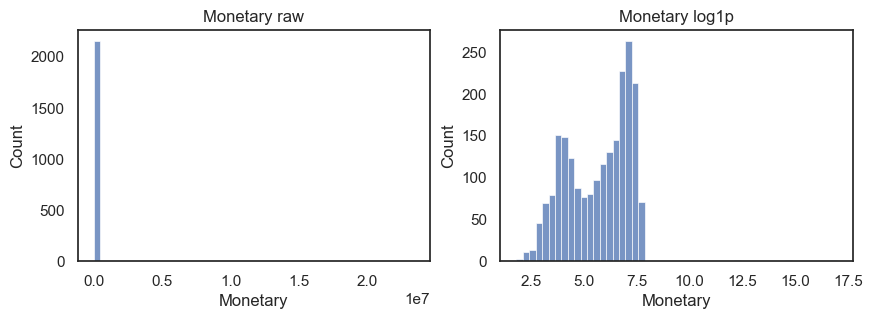

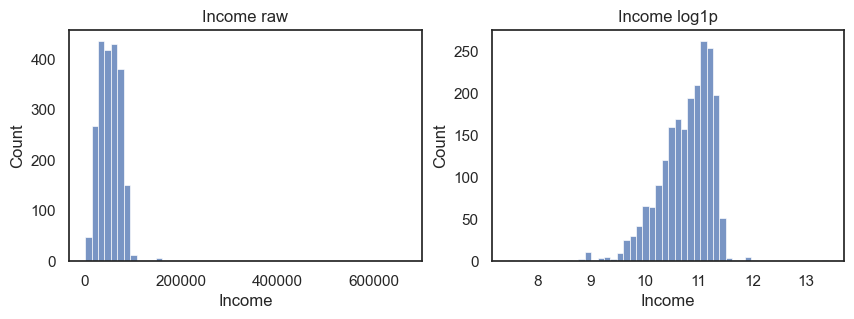

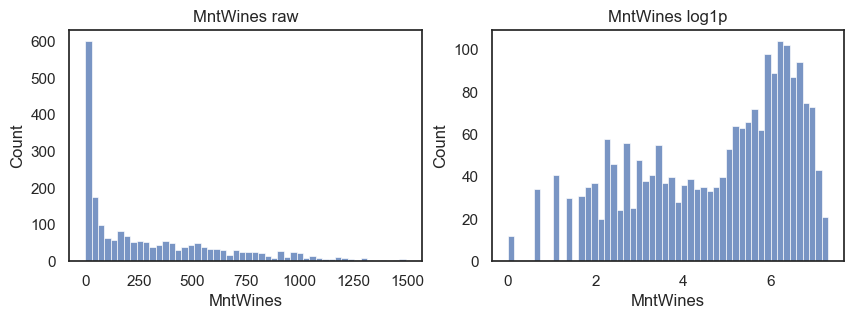

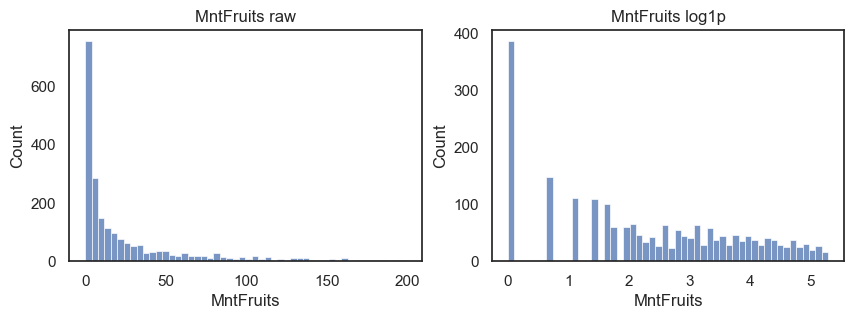

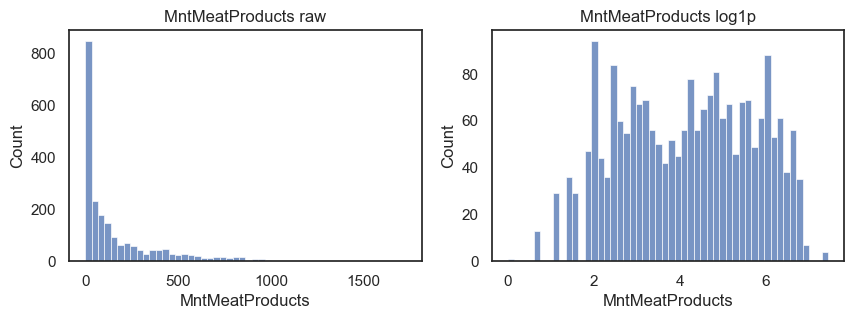

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


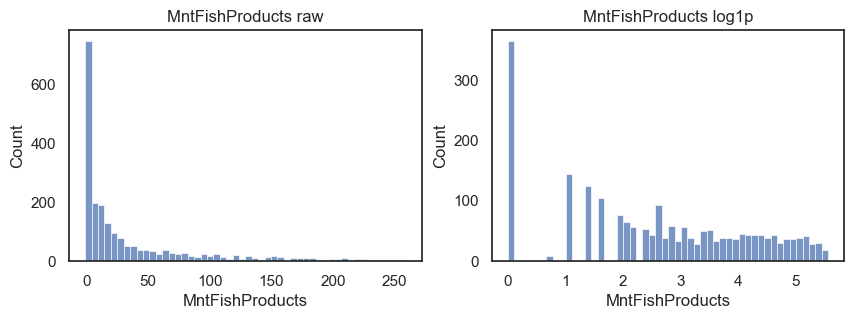

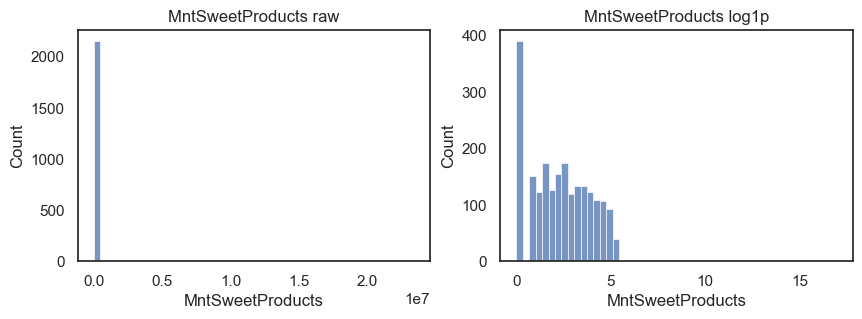

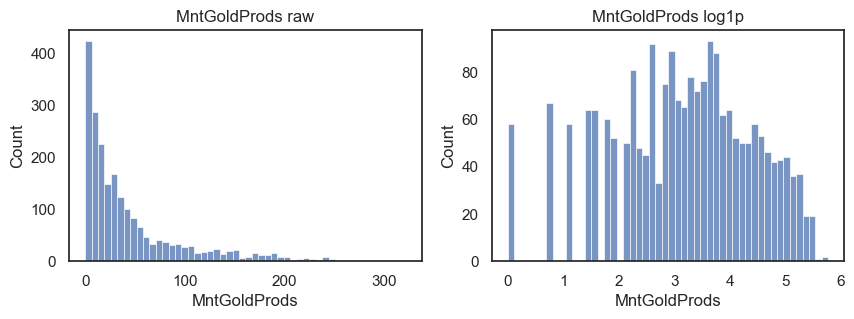

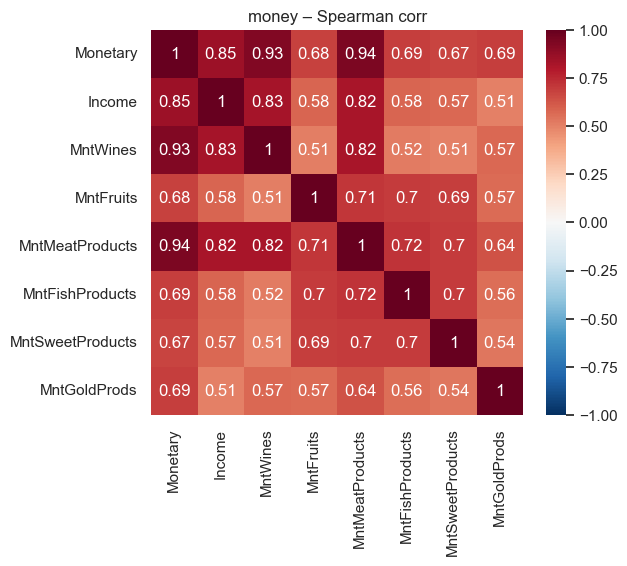


=== COUNT (6 vars) ===


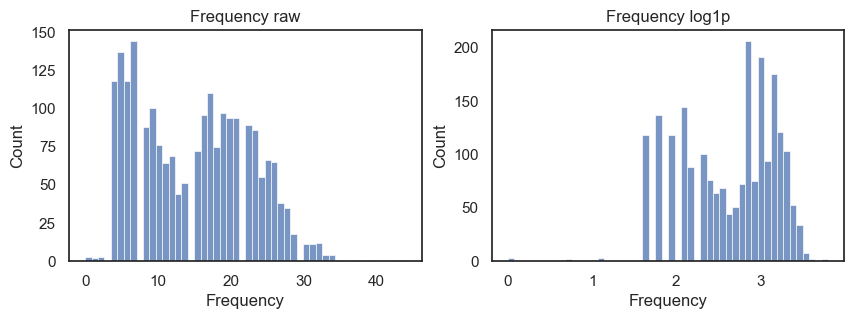

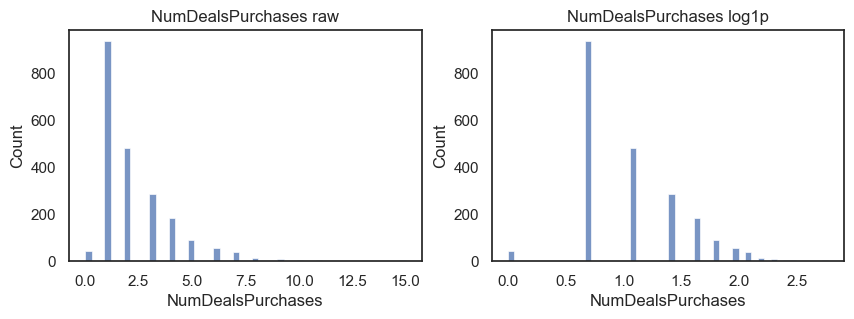

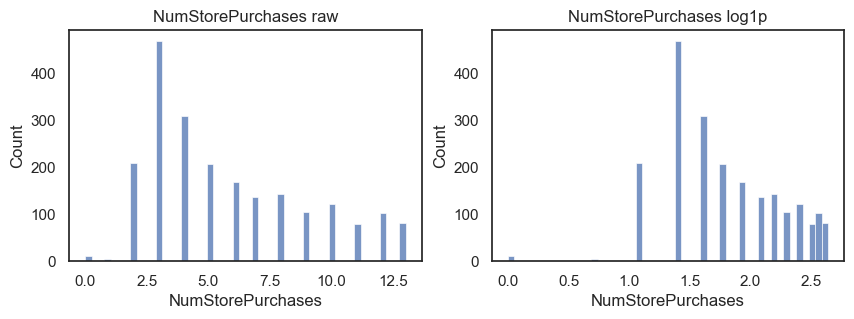

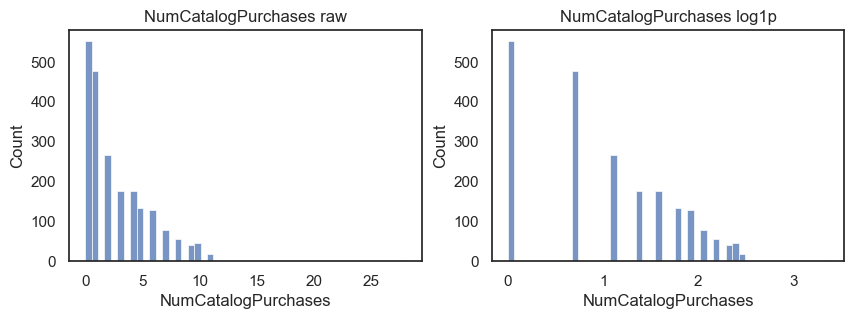

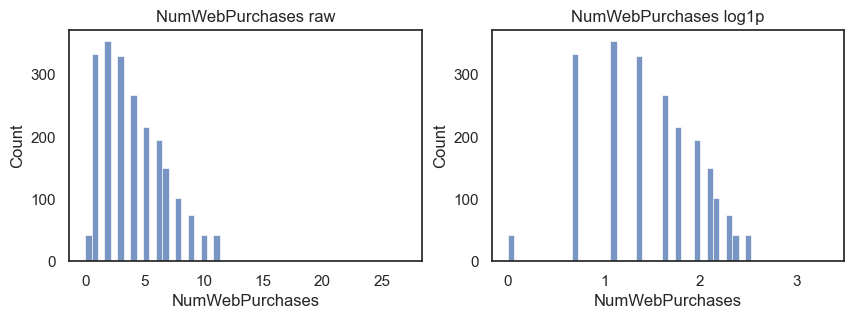

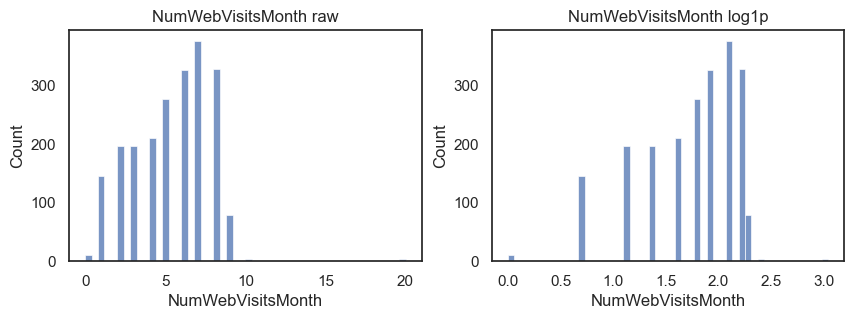

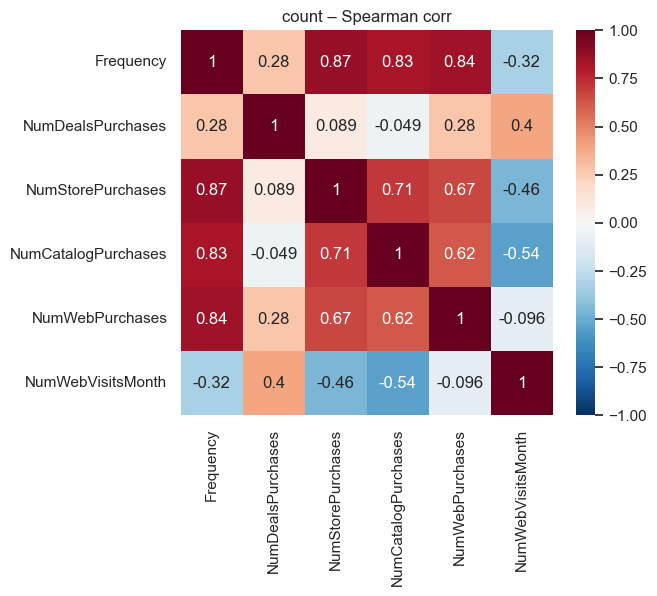


=== BASE_NUM (10 vars) ===


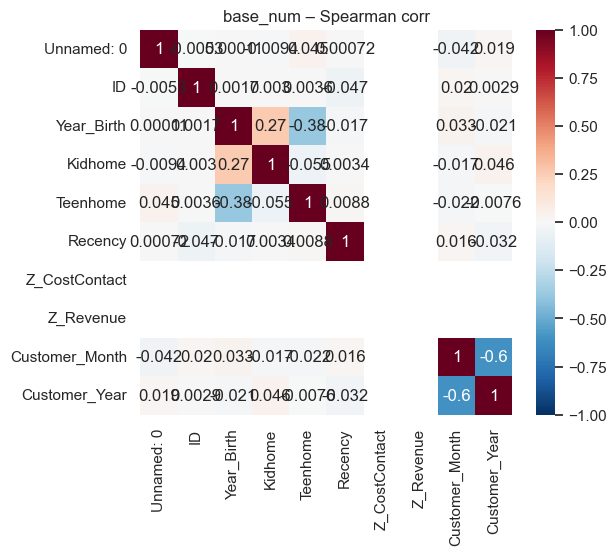


=== BOOL (6 vars) ===


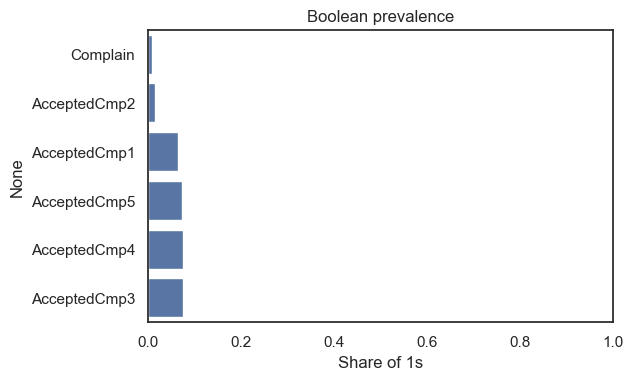


=== CAT (6 vars) ===


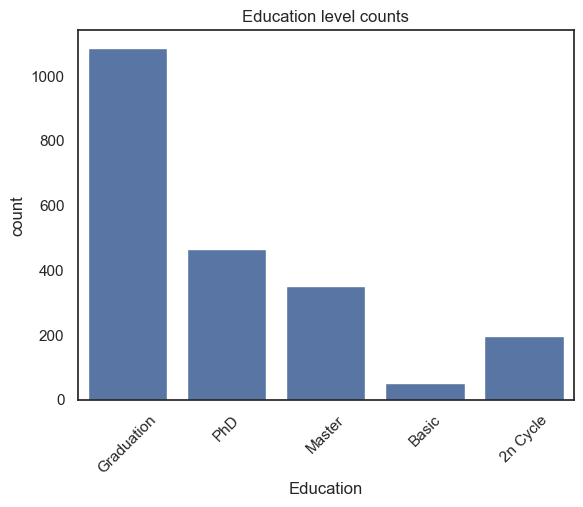

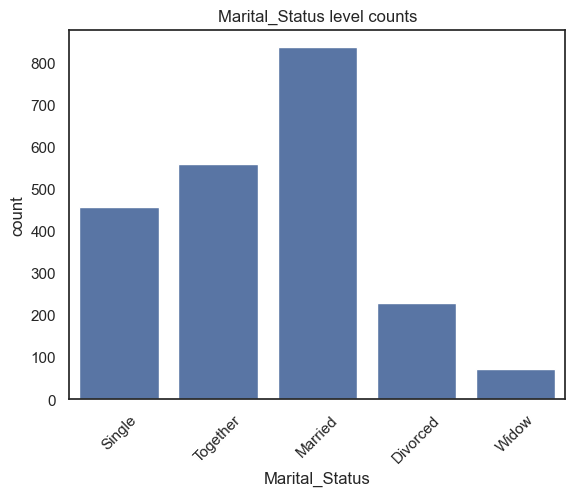

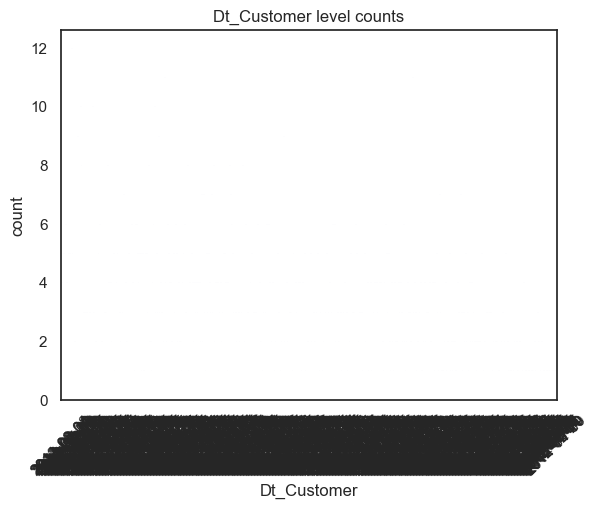

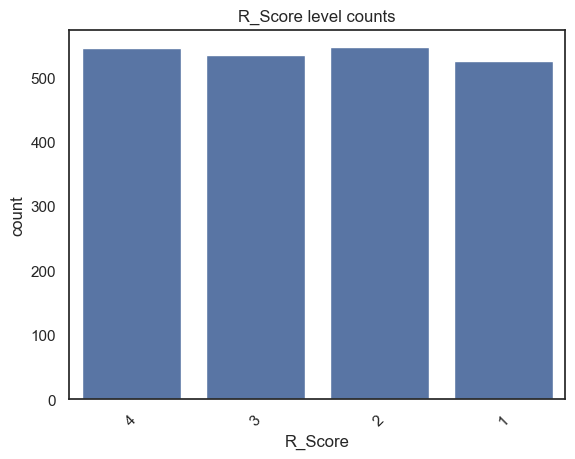

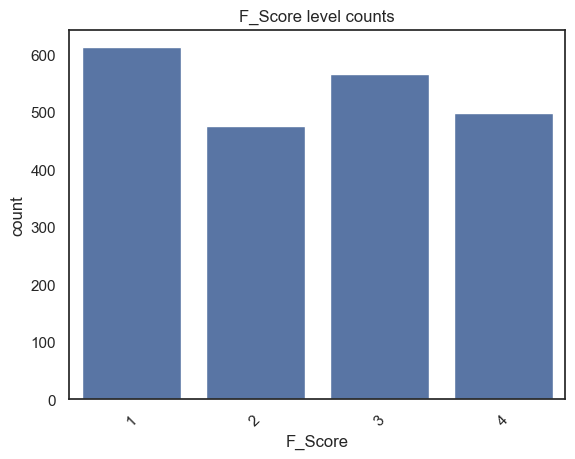

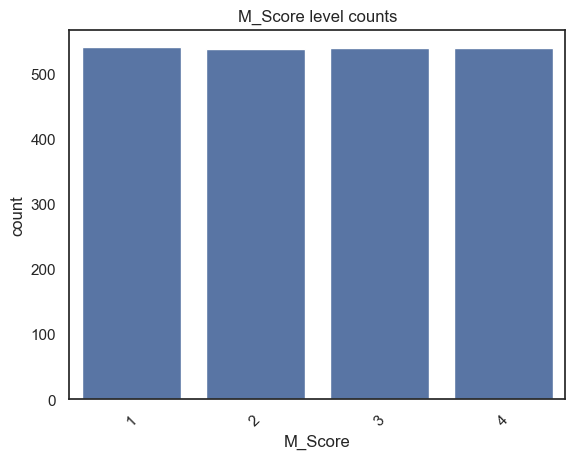

In [32]:
GROUPS = {
    "money" : money_cols,
    "count" : count_cols,
    "base_num" : num_cols,
    "bool"  : bool_cols,            # plot as bar of 0/1 prevalence
    "cat"   : cat_cols              # categorical counts
}

def quick_eda_groups(df, groups=GROUPS):
    for gname, cols in groups.items():
        if not cols:             # skip empty lists
            continue
        print(f"\n=== {gname.upper()} ({len(cols)} vars) ===")
        
        # --- Histograms / skew check -----------------------------------
        if gname in ("money", "count", "num"):
            for col in cols:
                fig, ax = plt.subplots(1, 2, figsize=(10, 3))
                sns.histplot(df[col], bins=50, ax=ax[0])
                ax[0].set_title(f"{col} raw")
                sns.histplot(np.log1p(df[col]), bins=50, ax=ax[1])
                ax[1].set_title(f"{col} log1p")
                plt.show()
        
        # --- Correlation heat-map for numeric groups -------------------
        if gname in ("money", "count", "base_num") and len(cols) > 1:
            plt.figure(figsize=(6,5))
            sns.heatmap(df[cols].corr('spearman'),
                        cmap='RdBu_r', vmin=-1, vmax=1, annot=True)
            plt.title(f"{gname} – Spearman corr"); plt.show()
        
        # --- Bool prevalence ------------------------------------------
        if gname == "bool":
            prevalence = df[cols].mean().sort_values()      # fraction of 1s
            plt.figure(figsize=(6, 0.3*len(prevalence)+2))
            sns.barplot(x=prevalence.values, y=prevalence.index, orient='h')
            plt.xlim(0, 1); plt.xlabel("Share of 1s"); plt.title("Boolean prevalence")
            plt.show()
        
        # --- Categorical level distribution ---------------------------
        if gname == "cat":
            for col in cols:
                sns.countplot(x=col, data=df)
                plt.title(f"{col} level counts"); plt.xticks(rotation=45)
                plt.show()

quick_eda_groups(df_model)


In [33]:
df_model['Monetary'].describe(percentiles=[.5, .9, .95, .99])


count    2.154000e+03
mean     1.268403e+04
std      5.072295e+05
min      5.000000e+00
50%      4.025000e+02
90%      1.542800e+03
95%      1.793050e+03
99%      2.174390e+03
max      2.342483e+07
Name: Monetary, dtype: float64

We will finally create one further variable, `Age` of the customer, and then drop the variables unecessary to the model training.


In [34]:
# find age using Year_Birth
df_model['Age'] = ((pd.to_datetime('today') -
                    pd.to_datetime(df_model['Year_Birth'], format='%Y')).dt.days // 365)
df_model = df_model.drop(columns=['Year_Birth'])


In [35]:
#drop all other columns that are irrelevant
df_model = df_model.drop(columns=['Customer_Month', 'Customer_Year', 'Z_Revenue', 'Z_CostContact'])


# 2. Modeling


* Prepare `X` and `y`


In [38]:
X = df_model.drop([    
    'Unnamed: 0', 
    'ID', 
    'Dt_Customer',
    'Response'
], 
    axis='columns'
) 

y = df_model['Response']


In [39]:
df_model.loc[df_model.Response == True].sample(4)


,Unnamed: 0,ID,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Frequency,Monetary,R_Score,F_Score,M_Score,Age
1288,1349,1745,PhD,Divorced,85696,0,0,2013-05-03,88,714.0,76.0,395,116,0,12.0,1,4,6,9,1,0,0,0,0,0,0,True,20,1313.0,1,3,4,63
816,854,5794,PhD,Married,46374,0,1,2014-03-17,1,408.0,0.0,21,0,0,17.0,3,7,1,7,8,0,1,0,1,0,0,True,18,446.0,4,3,3,51
1510,1585,1626,PhD,Divorced,35860,1,1,2014-05-19,37,15.0,0.0,8,4,2,20.0,2,1,1,2,5,1,0,0,0,0,0,True,6,49.0,3,1,1,52
704,735,7875,Graduation,Married,72025,0,0,2014-04-29,46,967.0,0.0,617,43,50,0.0,1,4,8,13,2,0,1,1,1,0,0,True,26,1677.0,3,4,4,76


In [40]:
df_model.shape


(2154, 33)

* Train and test split - 20%


In [42]:
# hold-out split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20,
    stratify=y,
    random_state=42
)


In [43]:
all_cols = X.columns                        # use the final columns only

money_cols = [c for c in money_cols  if c in all_cols]
count_cols = [c for c in count_cols  if c in all_cols]
num_cols   = [c for c in num_cols    if c in all_cols]
cat_cols   = [c for c in cat_cols    if c in all_cols]
bool_cols  = [c for c in bool_cols   if c in all_cols]


In [44]:
len(money_cols)


8

In [45]:
len(count_cols)


6

In [46]:
len(num_cols)


3

In [47]:
len(bool_cols)


6

In [48]:
len(cat_cols)


5

* Define our model pipeline  
We will apply subpipelines for each of the column groups. Before that, we define two functions, one to clip outliers above the 99% percentile and the other to apply the log1 function to normalize the distributions. These functions will be applied in the pipelines for the monetary and count variables.


In [50]:
# helper transformers
# remove outliers by clipping the top to the 99th percentile
clip99 = FunctionTransformer(
    lambda x: np.minimum(x, np.quantile(x, 0.99, axis=0)), validate=False
)

# compress right-skewed distributions
safe_log1p = FunctionTransformer(
    lambda x: np.log1p(np.clip(x, a_min=0, a_max=None)),
    validate=False
)
sqrt = FunctionTransformer(np.sqrt, validate=False)

# define subpipelines to transform each column group
money_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('clip', clip99),
    ('log', safe_log1p),
    ('scale', StandardScaler())
])

count_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('clip', clip99),
    ('log', safe_log1p),
    ('scale', StandardScaler())
])

num_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler())
])

cat_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('money', money_pipe, money_cols),
        ('count', count_pipe, count_cols),
        ('num', num_pipe, num_cols),
        ('cat', cat_pipe, cat_cols),
        ('bool', 'passthrough', bool_cols)
    ],
    remainder='drop',        
    verbose_feature_names_out=False 
)


Then we define the general pipeline, that includes the preprocessor that has already dealt with the subpipelines. We define the model - Logistic Regression - and the default hyperparameters. We apply a balancing method to the weights, since this is a highly unbalanced dataset.


In [51]:
log_reg_pipe = Pipeline([
    ('preproc', preprocessor),
    ('clf', LogisticRegression(
        penalty='l2',
        C=1.0,
        solver='liblinear',     
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])


Balancing the class weight in the pipeline is the quickest way to get the forest to pay more attention to the positive class and improve true-positive and F1.
However, it's not always the best. It's a coarse adjustment, there is a risk of overfitting minority noise and there is limited interaction with the feature space.

"Better" options can be:
* Smart resampling: SMOTE/ADASYN; clusteer-based undersampling
* Hybrid pipelines that use a small amount of oversampling plus a modest class weight
* Threshold and calibration tuning
* Ensemble of diverse learners
* Cost-sensitive learning / custom loss (XGBoost or LightGBM)

What “best” looks like
* Higher recall on class 1 without sacrificing too much precision on class 0
* Stable performance across cross-validation folds (low variance)
* Meaningful feature importances so your business can act on them
* Robustness to noise and small sample quirks


Then we define the Optuna hyperparameter tuning. We define a stratified K-Fold in 5 splits inside the train dataset, and the define the legal solvers, a way to stop L1 and L2 from having solvers that will not work. 
We define the objective function, and define which result metrics we want to see.


In [53]:
# Stratified 5-fold splitter (reuse across trials)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

LEGAL_SOLVERS = {
    "l1":        ["liblinear", "saga"],
    "l2":        ["lbfgs", "liblinear", "sag", "saga"],
    "elasticnet":["saga"]
}

#  objective
def objective(trial):

    penalty = trial.suggest_categorical("penalty", list(LEGAL_SOLVERS.keys()))
    solver  = trial.suggest_categorical("solver",  ["lbfgs", "liblinear", "saga"])
    
    # prune fast if pair is illegal
    if solver not in LEGAL_SOLVERS[penalty]:
        raise optuna.exceptions.TrialPruned()

    C          = trial.suggest_float("C", 1e-3, 100.0, log=True)
    class_wt   = trial.suggest_categorical("class_weight", [None, "balanced"])

    # extra hyper-param only for elastic-net
    l1_ratio = None
    if penalty == "elasticnet":
        l1_ratio = trial.suggest_float("l1_ratio", 0.0, 1.0)

    lr_params = {
        "penalty"     : penalty,
        "solver"      : solver,
        "C"           : C,
        "class_weight": class_wt,
        "max_iter"    : 1000,
        "random_state": 42
    }
    if l1_ratio is not None:
        lr_params["l1_ratio"] = l1_ratio

    model = Pipeline([
        ("preproc", preprocessor),             # your ColumnTransformer
        ("clf", LogisticRegression(**lr_params))
    ])

    scoring = {"auc": "roc_auc",
               "precision": "precision",
               "recall": "recall",
               "f1": "f1"}
    
    cv_res = cross_validate(model, 
                            X_train, 
                            y_train,
                            cv=cv, 
                            scoring=scoring, 
                            n_jobs=-1)

    auc   = cv_res["test_auc"].mean()
    prec  = cv_res["test_precision"].mean()
    rec   = cv_res["test_recall"].mean()
    f1    = cv_res["test_f1"].mean()

    if rec < 0.50:
        print("0.0")

    blended = 0.4*auc + 0.2*prec + 0.2*rec + 0.2*f1
    return blended


In [54]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=500, show_progress_bar=True)

print("Best blended score:", study.best_value)
print("Best hyper-params:",  study.best_params)


[I 2025-04-30 21:56:41,261] A new study created in memory with name: no-name-73244a6e-510d-4489-a9ce-f3ecb7969d29


  0%|          | 0/100 [00:00<?, ?it/s]

0.0
[I 2025-04-30 21:56:42,611] Trial 0 finished with value: 0.6844172151379481 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.1604700311266359, 'class_weight': None}. Best is trial 0 with value: 0.6844172151379481.
[I 2025-04-30 21:56:43,362] Trial 1 finished with value: 0.6766288297633981 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.0066924466492180555, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.6844172151379481.
[I 2025-04-30 21:56:43,364] Trial 2 pruned. 


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[I 2025-04-30 21:56:44,516] Trial 3 finished with value: 0.70970043513725 and parameters: {'penalty': 'l1', 'solver': 'saga', 'C': 92.18581313032549, 'class_weight': 'balanced'}. Best is trial 3 with value: 0.70970043513725.
[I 2025-04-30 21:56:44,621] Trial 4 finished with value: 0.7154776643934695 and parameters: {'penalty': 'l2', 'solver': 'lbfgs', 'C': 0.3746372303859675, 'class_weight': 'balanced'}. Best is trial 4 with value: 0.7154776643934695.
0.0
[I 2025-04-30 21:56:44,695] Trial 5 finished with value: 0.48190655407502664 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.004144167877481, 'class_weight': None}. Best is trial 4 with value: 0.7154776643934695.
[I 2025-04-30 21:56:44,696] Trial 6 pruned. 
[I 2025-04-30 21:56:44,697] Trial 7 pruned. 


...

[I 2025-04-30 21:56:52,373] Trial 48 finished with value: 0.7125078309433546 and parameters: {'penalty': 'l1', 'solver': 'saga', 'C': 17.88064356521303, 'class_weight': 'balanced'}. Best is trial 41 with value: 0.7180663617704542.
0.0
[I 2025-04-30 21:56:52,652] Trial 49 finished with value: 0.6988305606675009 and parameters: {'penalty': 'l1', 'solver': 'saga', 'C': 0.9766825459615177, 'class_weight': None}. Best is trial 41 with value: 0.7180663617704542.
[I 2025-04-30 21:56:53,043] Trial 50 finished with value: 0.7130124592523597 and parameters: {'penalty': 'l1', 'solver': 'saga', 'C': 1.7267287695661075, 'class_weight': 'balanced'}. Best is trial 41 with value: 0.7180663617704542.
[I 2025-04-30 21:56:53,236] Trial 51 finished with value: 0.7169485803665038 and parameters: {'penalty': 'l1', 'solver': 'saga', 'C': 0.42086672424316834, 'class_weight': 'balanced'}. Best is trial 41 with value: 0.7180663617704542.
[I 2025-04-30 21:56:53,453] Trial 52 finished with value: 0.71707017555078

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_

[I 2025-04-30 21:56:54,852] Trial 58 finished with value: 0.7109748502967773 and parameters: {'penalty': 'l1', 'solver': 'saga', 'C': 2.8643143496533354, 'class_weight': 'balanced'}. Best is trial 41 with value: 0.7180663617704542.
0.0
[I 2025-04-30 21:56:54,924] Trial 59 finished with value: 0.2562593464821902 and parameters: {'penalty': 'l1', 'solver': 'saga', 'C': 0.00214301093880661, 'class_weight': 'balanced'}. Best is trial 41 with value: 0.7180663617704542.
[I 2025-04-30 21:56:54,926] Trial 60 pruned. 
[I 2025-04-30 21:56:55,059] Trial 61 finished with value: 0.7181865019439281 and parameters: {'penalty': 'l1', 'solver': 'saga', 'C': 0.2566054205177789, 'class_weight': 'balanced'}. Best is trial 61 with value: 0.7181865019439281.
[I 2025-04-30 21:56:55,207] Trial 62 finished with value: 0.7179282663432722 and parameters: {'penalty': 'l1', 'solver': 'saga', 'C': 0.27244367736434694, 'class_weight': 'balanced'}. Best is trial 61 with value: 0.7181865019439281.
[I 2025-04-30 21:56:

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[I 2025-04-30 21:57:00,314] Trial 89 finished with value: 0.7097161873031728 and parameters: {'penalty': 'elasticnet', 'solver': 'saga', 'C': 84.34741366075481, 'class_weight': 'balanced', 'l1_ratio': 0.8979636117824144}. Best is trial 84 with value: 0.7184561898420131.
[I 2025-04-30 21:57:00,318] Trial 90 pruned. 
[I 2025-04-30 21:57:00,507] Trial 91 finished with value: 0.7164667024884254 and parameters: {'penalty': 'elasticnet', 'solver': 'saga', 'C': 0.5869326598452063, 'class_weight': 'balanced', 'l1_ratio': 0.6853224013769642}. Best is trial 84 with value: 0.7184561898420131.
[I 2025-04-30 21:57:00,648] Trial 92 finished with value: 0.7155816554673967 and parameters: {'penalty': 'elasticnet', 'solver': 'saga', 'C': 0.3549810765028817, 'class_weight': 'balanced', 'l1_ratio': 0.573144898267669}. Best is trial 84 with value: 0.7184561898420131.
[I 2025-04-30 21:57:00,795] Trial 93 finished with value: 0.7191934273384428 and parameters: {'penalty': 'elasticnet', 'solver': 'saga', 'C'

In [127]:
best_params = study.best_params
print(best_params)

# 2. Rebuild the pipeline with those params
best_model = Pipeline([
    ("preproc", preprocessor),                 # your ColumnTransformer
    ('clf', LogisticRegression(**best_params))
])

# 3. Fit once on the whole training data
best_model.fit(X_train, y_train)


{'penalty': 'elasticnet', 'solver': 'saga', 'C': 0.30199130858361845, 'class_weight': 'balanced', 'l1_ratio': 0.9198085069480795}


Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('money',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('clip',
                                                                   FunctionTransformer(func=<function <lambda> at 0x160d11800>)),
                                                                  ('log',
                                                                   FunctionTransformer(func=<function <lambda> at 0x160d12020>)),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['Monetary', 'Income',
                                                   'MntWines', 'MntFruits',
                                                   'MntMeatProducts...
                                                                                 handle_unknown='ignore'))]),
                                                  ['Education',
                                                   'Marital_Status', 'R_Score',
                                                   'F_Score', 'M_Score']),
                                                 ('bool', 'passthrough',
                                                  ['AcceptedCmp1',
                                                   'AcceptedCmp2',
                                                   'AcceptedCmp3',
                                                   'AcceptedCmp4',
                                                   'AcceptedCmp5',
                                                   'Complain'])],
                                   verbose_feature_names_out=False)),
                ('clf',
                 LogisticRegression(C=0.30199130858361845,
                                    class_weight='balanced',
                                    l1_ratio=0.9198085069480795,
                                    penalty='elasticnet', solver='saga'))])

In [56]:
preds = best_model.predict(X_test)
proba = best_model.predict_proba(X_test)[:, 1]


# 3. Evaluation


In [58]:
precision, recall, f1, support = precision_recall_fscore_support(
    y_test,
    preds,
    average=None                # one pair per class; use 'binary' or 'macro' if you want a single average
)

# 4. Round and print
print("Class 0 — Precision: {:.3f}, Recall: {:.3f}, F1: {:.3f}, Support: {}".format(
    precision[0], recall[0], f1[0], support[0]
))
print("Class 1 — Precision: {:.3f}, Recall: {:.3f}, F1: {:.3f}, Support: {}".format(
    precision[1], recall[1], f1[1], support[1]
))


Class 0 — Precision: 0.960, Recall: 0.850, F1: 0.901, Support: 366
Class 1 — Precision: 0.486, Recall: 0.800, F1: 0.605, Support: 65


In [135]:
print(classification_report(y_test, preds, digits=3))


              precision    recall  f1-score   support

       False      0.960     0.850     0.901       366
        True      0.486     0.800     0.605        65

    accuracy                          0.842       431
   macro avg      0.723     0.825     0.753       431
weighted avg      0.888     0.842     0.857       431



* Creating a `results` dataframe to hold our probabilities of being positive, our prediction and the ground truth reality


In [137]:
results = pd.DataFrame()

results['proba_true'] = proba
results['prediction'] = preds
results['ground_truth'] = y_test.values

results.head()


,proba_true,prediction,ground_truth
0,0.139357,False,False
1,0.413061,False,False
2,0.807784,True,False
3,0.415270,False,False
4,0.155048,False,False


* Probability of a sample being POSITIVE (X = 1) for X = 0 and X = 1 separately  
A (true X = 0) – Most negative cases get very small predicted probabilities of being 1 (clustered below ≈ 0.20). Only a thin tail of negatives receives a probability above 0.5, so false-positive risk is low.  
B (true X = 1) – Most positive cases get large probabilities (peaking around 0.85-1.0). A minority fall below 0.5, so those would be the false-negatives.


:Layout
   .Histogram.I  :Histogram   [proba_true]   (proba_true_count)
   .Histogram.II :Histogram   [proba_true]   (proba_true_count)
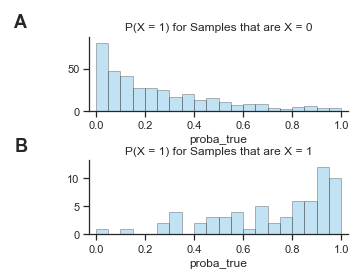

In [139]:
(
    results.loc[
        results.ground_truth == 0
    ].hvplot.hist(
        y='proba_true', 
        bin_range=(0,1), 
        bins=20,
        color='green',
        alpha=0.3,
        legend='bottom',
        label='REAL 0',
        height=200,
        title='P(X = 1) for Samples that are X = 0'
    ) + \
    results.loc[
        results.ground_truth == 1
    ].hvplot.hist(
        y='proba_true', 
        bin_range=(0,1), 
        bins=20,
        color='red',
        alpha=0.3,
        label='REAL 1',
        height=200,
        title='P(X = 1) for Samples that are X = 1'
    )
).cols(1).opts(shared_axes=False)


* Model's feature importance


/opt/anaconda3/lib/python3.12/site-packages/holoviews/plotting/mpl/renderer.py:219: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from current font.
  fig.canvas.draw()
/opt/anaconda3/lib/python3.12/site-packages/holoviews/plotting/mpl/renderer.py:171: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


:Bars   [feature]   (coef)
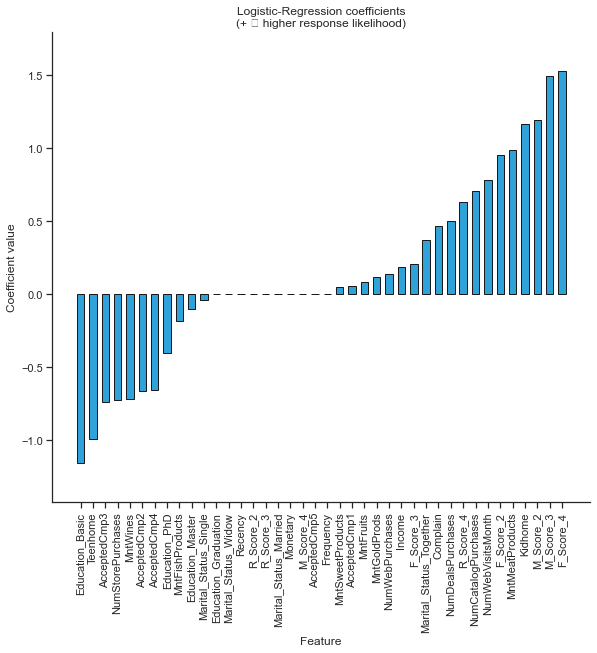

In [141]:
preproc      = best_model.named_steps["preproc"]
ohe          = preproc.named_transformers_["cat"].named_steps["onehot"]

money_feat   = money_cols
count_feat   = count_cols
bool_feat    = bool_cols
num_feat     = num_cols
cat_feat_out = ohe.get_feature_names_out(cat_cols)

feature_names = np.concatenate([
    money_feat,
    count_feat,
    bool_feat,
    num_feat,
    cat_feat_out
])


# 6) Build your series & plot
coefs = best_model.named_steps["clf"].coef_.ravel()
coef_series = (
    pd.Series(coefs, index=feature_names, name="coefficient")
      .sort_values()
)

df = coef_series.reset_index().rename(columns={"index":"feature", "coefficient":"coef"})
df.hvplot.bar(
    x="feature", y="coef",
    height=700, width=800,
    title="Logistic-Regression coefficients\n(+ ⇒ higher response likelihood)",
    xlabel="Feature",
    ylabel="Coefficient value",
    rot=90
)


* Confusion Matrix of our Test Set


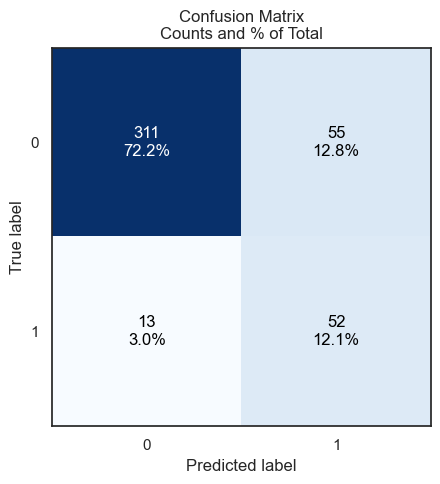

In [143]:
# 1) Compute the matrix
cm = confusion_matrix(y_test, preds)
cm_pct = cm / cm.sum()  # overall percentage

# 2) Create the display WITHOUT internal annotations
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
fig, ax = plt.subplots(figsize=(5,5))
disp.plot(
    ax=ax,
    include_values=False,   # <— disable the default counts
    colorbar=False,
    cmap="Blues"
)

# 3) Add your own count+percent, with dynamic text color for readability
nrows, ncols = cm.shape
for i in range(nrows):
    for j in range(ncols):
        count = cm[i, j]
        pct   = cm_pct[i, j] * 100
        # pick white text on dark cells, black on light cells
        bg = cm_pct[i, j]
        text_color = "white" if bg > 0.5 else "black"
        ax.text(
            j, i,
            f"{count}\n{pct:.1f}%",
            ha="center", va="center",
            fontsize=12,
            color=text_color
        )

ax.set_title("Confusion Matrix\nCounts and % of Total")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()


* Most samples are class 0 (negatives).
* The model gets negatives right 85 % of the time (311 / 366); only 15 % are mistakenly flagged as positives (55 FP).
* For the minority class 1 (positives), it catches 80 % (52 / 65) but misses 20 % (13 FN).
* Overall accuracy ≈ 84 % (363 / 431), driven largely by the abundant negatives.
* Precision for the positive class is roughly 49 % (52 / 107), meaning about half of the predicted positives are truly positive.

So the classifier is fairly good at recognising positives (high recall) and very good at rejecting negatives, but its positive predictions are only moderately reliable because of the 55 false alarms.


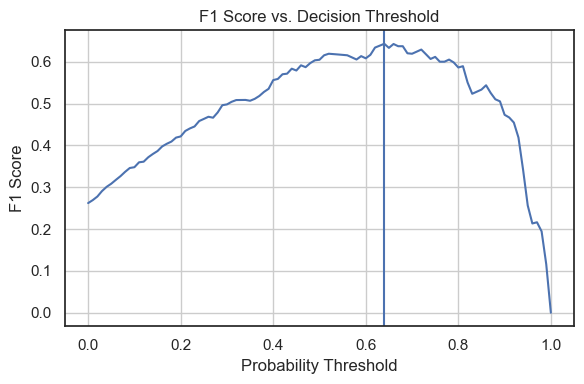

Best threshold: 0.640  →  F1 = 0.643


In [145]:
# 1) Get true labels and predicted probabilities on your hold-out set
y_true = y_test
# already computed up there
# proba   = basic_pipe.predict_proba(X_test)[:, 1]

# 3) Sweep thresholds and compute F1
thresholds = np.linspace(0, 1, 101)
f1_scores  = [f1_score(y_true, proba >= t) for t in thresholds]

# 4) Find the best threshold
best_idx       = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1        = f1_scores[best_idx]

# 5) Plot F1 vs. threshold and mark best
plt.figure(figsize=(6, 4))
plt.plot(thresholds, f1_scores)
plt.axvline(best_threshold)                # vertical line at best threshold
plt.xlabel("Probability Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs. Decision Threshold")
plt.grid(True)
plt.tight_layout()
plt.show()

# 6) Report the best threshold
print(f"Best threshold: {best_threshold:.3f}  →  F1 = {best_f1:.3f}")


▶ Optimal threshold = 0.64 → Profit €270.0
  Precision @ 0.64 = 60.00%
  Recall    @ 0.64 = 69.23%


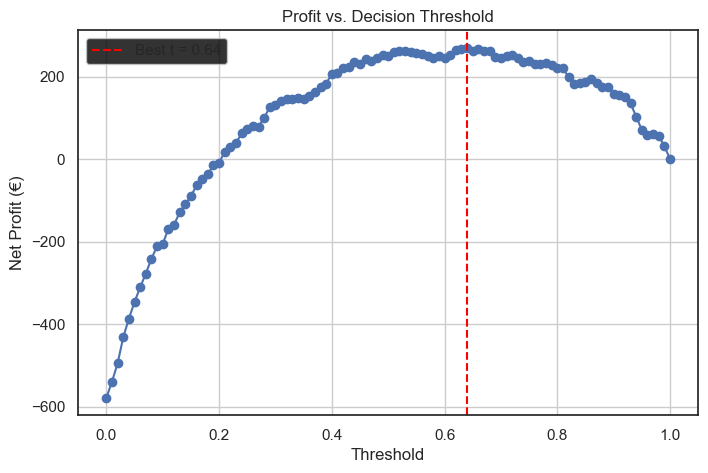

In [147]:
# 1. Build a grid of thresholds
thresholds = np.linspace(0.0, 1.0, 101)

# 2. For each threshold, compute TP, FP, precision, recall, and profit
records = []
for t in thresholds:
    # apply threshold
    preds_t = (proba >= t).astype(int)

    # confusion matrix: tn, fp, fn, tp
    tn, fp, fn, tp = confusion_matrix(y_test, preds_t).ravel()

    # compute precision/recall if you want
    precision_t = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall_t    = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    # compute profit: +8€ per TP, –3€ per FP
    profit_t = 8 * tp - 3 * fp

    records.append({
        'threshold':    t,
        'TP':           tp,
        'FP':           fp,
        'precision':    precision_t,
        'recall':       recall_t,
        'profit':       profit_t
    })

df_thresh = pd.DataFrame(records)

# 3. Find your optimal threshold
best_idx      = df_thresh['profit'].idxmax()
best_row      = df_thresh.loc[best_idx]
best_thr      = best_row['threshold']
best_profit   = best_row['profit']
best_precision= best_row['precision']
best_recall   = best_row['recall']

print(f"▶ Optimal threshold = {best_thr:.2f} → Profit €{best_profit}")
print(f"  Precision @ {best_thr:.2f} = {best_precision:.2%}")
print(f"  Recall    @ {best_thr:.2f} = {best_recall:.2%}")

# 4. Plot Profit vs Threshold
plt.figure(figsize=(8,5))
plt.plot(df_thresh['threshold'], df_thresh['profit'], marker='o', linestyle='-')
plt.axvline(best_thr, color='red', linestyle='--',
            label=f"Best t = {best_thr:.2f}")
plt.xlabel('Threshold')
plt.ylabel('Net Profit (€)')
plt.title('Profit vs. Decision Threshold')
plt.legend()
plt.grid(True)
plt.show()


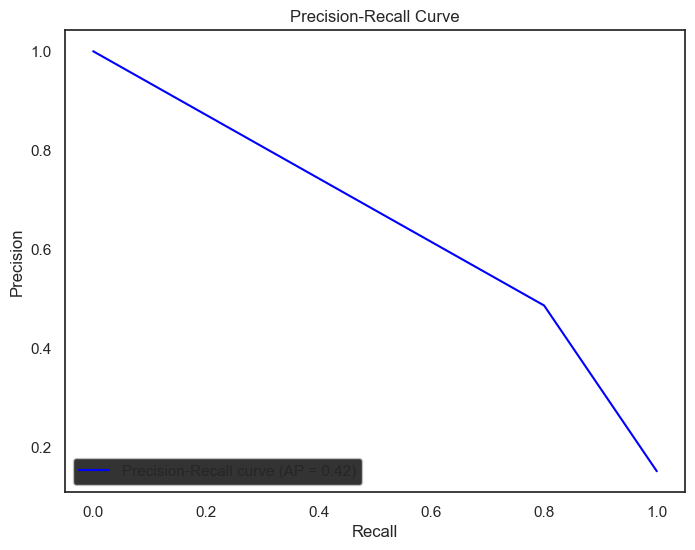

In [149]:
# Compute Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, preds)
avg_precision = average_precision_score(y_test, preds)

# Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', label=f'Precision-Recall curve (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()


In [167]:
# at top of your script (or better, in a library .py module):
def my_transformer(X):
    # …whatever your lambda did…
    return X_processed

# then build your pipeline:
from sklearn.preprocessing import FunctionTransformer
preproc = FunctionTransformer(my_transformer)


With the decision threshold shifted to 0.64, the classifier delivers an estimated €270 net profit on the test set, achieving roughly 60 % precision and 69 % recall for the positive class; that means about six in ten alerts are truly positive and the model still captures close to seven in ten of all positives while keeping false-negative and false-positive counts at business-tolerable levels. Overall accuracy (≈ 84 %) is buoyed by a class imbalance (many more negatives than positives), but the profit curve confirms the model adds value relative to doing nothing or using the default 0.50 cut-off. Provided those cost and revenue assumptions are sound—and given the modest sample size warrants cautious roll-out—the model is suitable for deployment as a minimum-viable solution so long as you lock in the 0.64 threshold, monitor performance and drift, and be prepared to refine it as more data arrive or cost structures change.m


This is the strongest model when it comes to its confidence in its predictions. However, when taking into consideration the confusion matrix, it's catching more False Positives then True Positives, despite being, out of the 3 models, the one that catches more True Positives. 
Furthermore, in terms of profit, it has a lower profit than the MLP model. If we consider that to be the defining metric when looking at it through a marketing perspective, the MLP is the best choice.
